# TS5 (Estimación espectral: ventanas en acción)

Senoidal de potencia unitaria con desintonía aleatoria respecto a la grilla de la DFT,
`Ω1 = Ω0 + fr·2π/N`, con `Ω0 = π/2` y `fr ~ U(-2, 2)`, contaminada con ruido `N(0, σ²)`.
Sobre 200 realizaciones de 1000 muestras se evalúan, para distintas ventanas:
- Estimador de amplitud `â = 2·|X_w(Ω0)|/Σw`
- Estimador de frecuencia `Ω̂1 = argmax |X_w(Ω)|`
- Sesgo y varianza de cada estimador para SNR de 3 y 10 dB
- Efecto del zero-padding sobre el estimador de frecuencia


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# Parámetros
fs   = 1000                     # Hz, frecuencia de muestreo
N    = 1000                     # muestras por realización
M    = 200                      # realizaciones
a0   = np.sqrt(2)               # amplitud → P = a0²/2 = 1 W
Om0  = np.pi / 2                # frecuencia central
k0   = N // 4                   # bin de Om0 = pi/2  →  Om0/(2pi)*N = 250
f0   = Om0 * fs / (2 * np.pi)   # 250 Hz

snr_list  = [3, 10]             # dB
nfft_freq = 10 * N              # zero-padding para el estimador de frecuencia

## Señal

Desintonía aleatoria `fr` (corrimiento en bins respecto a la grilla) y senoidal asociada.

In [2]:
n   = np.arange(N)
rng = np.random.default_rng(2026)

# Desintonía: Om1 = Om0 + fr·(2pi/N),  fr ~ U(-2, 2)
fr  = rng.uniform(-2, 2, M)
Om1 = Om0 + fr * 2 * np.pi / N

# Señal senoidal (misma para todas las ventanas y SNR), shape (M, N)
S  = a0 * np.sin(Om1[:, None] * n[None, :])
f1 = Om1 * fs / (2 * np.pi)    # frecuencia verdadera por realización [Hz]

## Ventanas

Rectangular (sin ventana), flat-top, blackman-harris y hann.

In [3]:
ventanas = {
    'Rectangular':     np.ones(N),
    'Flat-top':        windows.flattop(N),
    'Blackman-Harris': windows.blackmanharris(N),
    'Hann':            windows.hann(N),
}
colors = ['steelblue', 'orangered', 'seagreen', 'mediumpurple']

## Estimadores

La amplitud se mide en el bin `k0` con normalización por ganancia coherente.
La frecuencia se obtiene por `argmax` del espectro con zero-padding.

In [4]:
def experimento(snr_db):
    """Devuelve dicts {ventana: (sesgo, varianza)} para amplitud y frecuencia."""
    sigma = np.sqrt(10 ** (-snr_db / 10))          # P_senoidal = 1 W
    x     = S + sigma * rng.standard_normal((M, N))

    amp_est, frq_est, res_amp, res_frq = {}, {}, {}, {}
    for nombre, w in ventanas.items():
        xw = x * w

        # Amplitud: |X_w(Om0)| en el bin k0, normalizado por la ganancia coherente
        X   = np.fft.fft(xw, axis=1)
        a_h = 2 * np.abs(X[:, k0]) / np.sum(w)

        # Frecuencia: argmax con zero-padding
        Xz  = np.fft.rfft(xw, n=nfft_freq, axis=1)
        f_h = np.argmax(np.abs(Xz), axis=1) * fs / nfft_freq

        amp_est[nombre] = a_h
        frq_est[nombre] = f_h
        res_amp[nombre] = (a_h.mean() - a0, a_h.var())
        res_frq[nombre] = (f_h.mean() - f0, f_h.var())

    return res_amp, res_frq, amp_est, frq_est


def tabla(titulo, res, ref):
    print(f"\n{titulo}   (referencia = {ref})")
    print(f"{'':18s}{'sesgo':>12s}{'varianza':>14s}")
    for nombre, (s, v) in res.items():
        print(f"{nombre:18s}{s:12.5f}{v:14.6f}")

## Tablas por SNR

In [5]:
amp_por_snr = {}
frq_por_snr = {}
for snr in snr_list:
    res_amp, res_frq, amp_est, frq_est = experimento(snr)
    amp_por_snr[snr] = amp_est
    frq_por_snr[snr] = frq_est
    print("=" * 46)
    print(f"SNR = {snr} dB")
    tabla("Estimación de amplitud", res_amp, f"a0 = {a0:.4f}")
    tabla("Estimación de frecuencia [Hz]", res_frq, f"f0 = {f0:.1f}")

SNR = 3 dB

Estimación de amplitud   (referencia = a0 = 1.4142)
                         sesgo      varianza
Rectangular           -0.84869      0.201554
Flat-top              -0.10255      0.021358
Blackman-Harris       -0.43542      0.128719
Hann                  -0.62448      0.220724

Estimación de frecuencia [Hz]   (referencia = f0 = 250.0)
                         sesgo      varianza
Rectangular            0.01950      1.165770
Flat-top               0.02000      1.380300
Blackman-Harris        0.01600      1.166344
Hann                   0.01850      1.164408
SNR = 10 dB

Estimación de amplitud   (referencia = a0 = 1.4142)
                         sesgo      varianza
Rectangular           -0.84894      0.202993
Flat-top              -0.09899      0.020123
Blackman-Harris       -0.43240      0.129752
Hann                  -0.62381      0.225099

Estimación de frecuencia [Hz]   (referencia = f0 = 250.0)
                         sesgo      varianza
Rectangular            0.02100   

## Estimador de amplitud

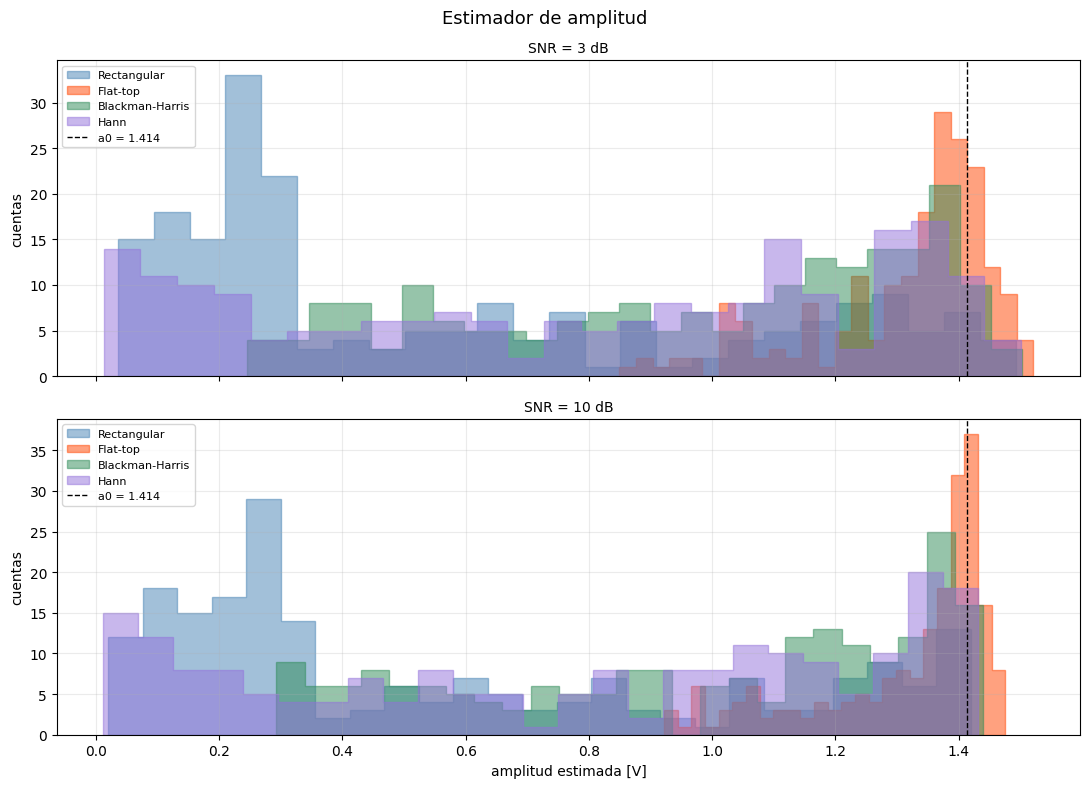

In [6]:
fig1, axes1 = plt.subplots(len(snr_list), 1, figsize=(11, 8), sharex=True)
fig1.suptitle('Estimador de amplitud', fontsize=13)

for ax, snr in zip(axes1, snr_list):
    for (nombre, a_h), c in zip(amp_por_snr[snr].items(), colors):
        ax.hist(a_h, bins=25, histtype='stepfilled', alpha=0.5, color=c,
                edgecolor=c, label=nombre)
    ax.axvline(a0, color='k', ls='--', lw=1, label=f'a0 = {a0:.3f}')
    ax.set_title(f'SNR = {snr} dB', fontsize=10)
    ax.set_ylabel('cuentas')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
axes1[-1].set_xlabel('amplitud estimada [V]')

plt.tight_layout()
plt.show()

## Estimador de frecuencia

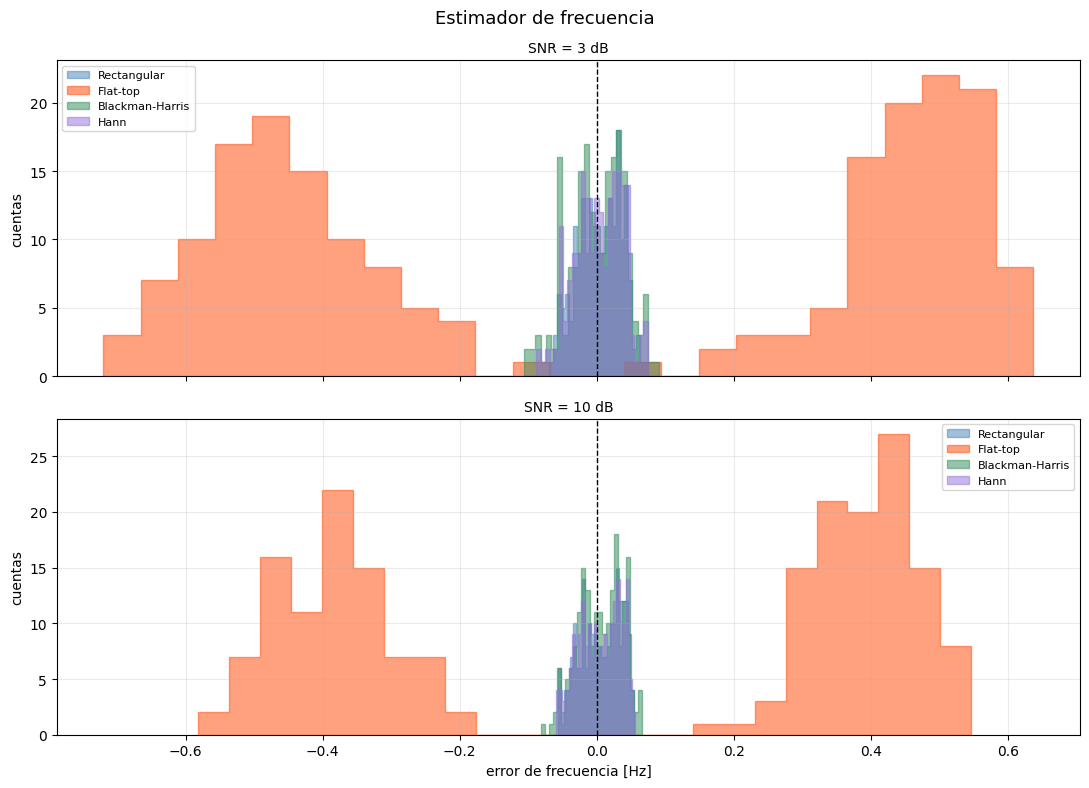

In [7]:
fig2, axes2 = plt.subplots(len(snr_list), 1, figsize=(11, 8), sharex=True)
fig2.suptitle('Estimador de frecuencia', fontsize=13)

for ax, snr in zip(axes2, snr_list):
    for (nombre, f_h), c in zip(frq_por_snr[snr].items(), colors):
        ax.hist(f_h - f1, bins=25, histtype='stepfilled', alpha=0.5, color=c,
                edgecolor=c, label=nombre)
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_title(f'SNR = {snr} dB', fontsize=10)
    ax.set_ylabel('cuentas')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
axes2[-1].set_xlabel('error de frecuencia [Hz]')

plt.tight_layout()
plt.show()

## Zero padding

Efecto del factor de zero-padding sobre la varianza del estimador de frecuencia (SNR = 10 dB).

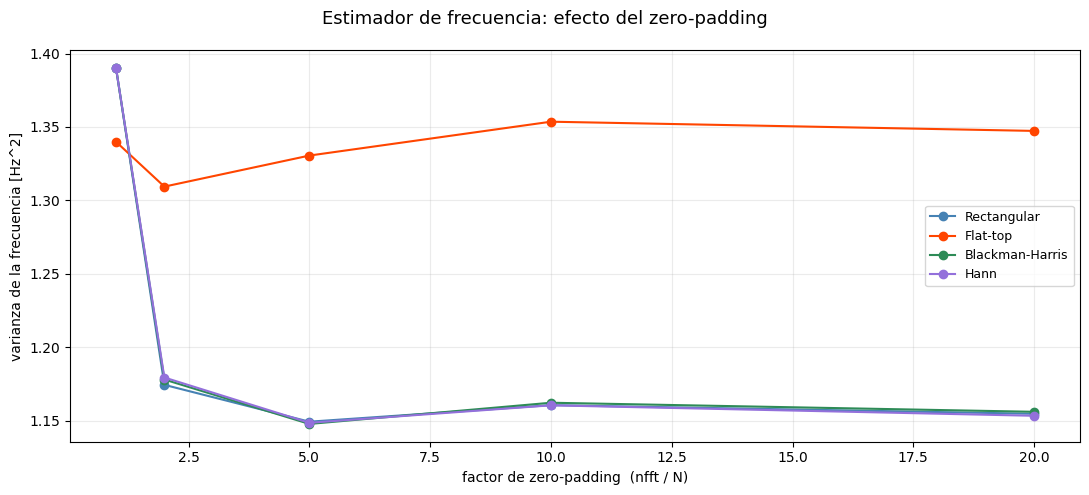

In [8]:
factores  = [1, 2, 5, 10, 20]
snr_bonus = 10
sigma     = np.sqrt(10 ** (-snr_bonus / 10))
x_b       = S + sigma * rng.standard_normal((M, N))

fig3, ax3 = plt.subplots(figsize=(11, 5))
fig3.suptitle('Estimador de frecuencia: efecto del zero-padding', fontsize=13)

for (nombre, w), c in zip(ventanas.items(), colors):
    xw   = x_b * w
    varf = []
    for fac in factores:
        Xz  = np.fft.rfft(xw, n=fac * N, axis=1)
        f_h = np.argmax(np.abs(Xz), axis=1) * fs / (fac * N)
        varf.append(f_h.var())
    ax3.plot(factores, varf, marker='o', color=c, lw=1.5, label=nombre)

ax3.set_xlabel('factor de zero-padding  (nfft / N)')
ax3.set_ylabel('varianza de la frecuencia [Hz^2]')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()